# OOD Detection with GSVD experiment notebook

This notebook combines the five ablation experiments for detecting out-of-distribution (OOD) images using the Generalized Singular Value Decomposition (GSVD) between an expert and a novice feature extractor.

### The idea 

If you pair a strong pretrained model (expert) with a randomly initialized one (novice), the alignment of their features on an image tells you something about whether the image is in-distribution or not. The expert has learned meaningful visual structure; the novice is basically a random projection. When the expert sees something it knows, its features have structure the novice lacks. On an OOD image the expert is more "confused" and behaves a bit more like a random feature extractor, so the gap shrinks and the GSVD ratios shift.

### Setup

| piece | what was used |
| --- | --- |
| Expert | DINOv3 ViT-B/16 (pretrained, frozen) |
| Novice | Random-init SegFormer-B5 or simpler CNN |
| ID data | Cityscapes val (Tübingen, Ulm, Weimar, Zurich) |
| OOD data | Fishyscapes + AnomalyTrack |
| Domain-shift control | BDD100K (real-world shift, no anomalies) |

### The five experiments

1. **Exp 1** – How do I aggregate the GSVD ratios into one score? (mean / median / max)
2. **Exp 2** – Does the novice need to be complex, or is a tiny CNN enough?
3. **Exp 3** – How many GSVD ratios do I actually need?
4. **Exp 4** – Does it still work with a pretrained SegFormer as expert (instead of DINOv3)?
5. **Exp 5** – Is the score really detecting *anomalies*, or just distribution shift / brightness?

## 1. Imports

In [37]:
import os, glob, csv, random

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F

import matplotlib.pyplot as plt
from PIL import Image, ImageFilter
from sklearn.metrics import roc_auc_score, roc_curve
from tqdm.auto import tqdm
import pandas as pd

import timm
from transformers import SegformerForSemanticSegmentation, SegformerConfig
from torchvision.transforms.v2 import (
    Compose, ToImage, Resize, ToDtype, Normalize, InterpolationMode,
)

# Set up matplotlib parameters for plotting
plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["figure.dpi"] = 100

## 2. Paths and global config

If I move the data or the weights somewhere else, this is the only cell I need to edit.

In [38]:
# Project root 
BASE = "/Users/mirjamh/Documents/Projects/Neural networks for computer vision/NNCV-MoreJamplz"

# Model weights
DINO_WEIGHTS      = f"{BASE}/weights/dinov3_vitb16_timm.pth"
SEGFORMER_WEIGHTS = f"{BASE}/weights/segformer.pt"

# Dataset paths
CITYSCAPES_VAL = f"{BASE}/datasets/ID data/cityscapes/leftImg8bit/val"
BDD_DIR        = f"{BASE}/datasets/ID data/bdd100k_500"
ANOMALY_DIR    = f"{BASE}/datasets/OOD data/dataset_AnomalyTrack/images"
FISHY_DIR      = f"{BASE}/datasets/OOD data/fishyscapes_rgb_100"

# I only use the validation set of Cityscapes for ID data
ID_FOLDERS = [
    f"{CITYSCAPES_VAL}/tubingen",
    f"{CITYSCAPES_VAL}/ulm",
    f"{CITYSCAPES_VAL}/weimar",
    f"{CITYSCAPES_VAL}/zurich",
]
OOD_FOLDERS     = [FISHY_DIR, ANOMALY_DIR]
DS_REAL_FOLDERS = [BDD_DIR]

# Experiments config
SEED       = 1
INPUT_SIZE = (512, 512)
DEVICE = (
    "cuda" if torch.cuda.is_available()
    else "mps" if torch.backends.mps.is_available()
    else "cpu"
)
print("Using device:", DEVICE)

# Where CSVs and plots go
RESULTS_ROOT = "results"
os.makedirs(RESULTS_ROOT, exist_ok=True)

Using device: mps


### Quick path sanity check

In [39]:
for p in [DINO_WEIGHTS, SEGFORMER_WEIGHTS, *ID_FOLDERS, *OOD_FOLDERS, *DS_REAL_FOLDERS]:
    print(("ok  " if os.path.exists(p) else "MISS"), p)

ok   /Users/mirjamh/Documents/Projects/Neural networks for computer vision/NNCV-MoreJamplz/weights/dinov3_vitb16_timm.pth
ok   /Users/mirjamh/Documents/Projects/Neural networks for computer vision/NNCV-MoreJamplz/weights/segformer.pt
ok   /Users/mirjamh/Documents/Projects/Neural networks for computer vision/NNCV-MoreJamplz/datasets/ID data/cityscapes/leftImg8bit/val/tubingen
ok   /Users/mirjamh/Documents/Projects/Neural networks for computer vision/NNCV-MoreJamplz/datasets/ID data/cityscapes/leftImg8bit/val/ulm
ok   /Users/mirjamh/Documents/Projects/Neural networks for computer vision/NNCV-MoreJamplz/datasets/ID data/cityscapes/leftImg8bit/val/weimar
ok   /Users/mirjamh/Documents/Projects/Neural networks for computer vision/NNCV-MoreJamplz/datasets/ID data/cityscapes/leftImg8bit/val/zurich
ok   /Users/mirjamh/Documents/Projects/Neural networks for computer vision/NNCV-MoreJamplz/datasets/OOD data/fishyscapes_rgb_100
ok   /Users/mirjamh/Documents/Projects/Neural networks for computer vi

## 3. Seeding

Because the novice is randomly initialized, the score for every image depends on that random init. For reprodicibility purposes I seed it. 

In [40]:
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

## 4. GSVD algorithm 

In [41]:
def gsvd0(A: np.ndarray, B: np.ndarray):

    """Compute the generalized singular value decomposition (GSVD) of two matrices A and B.
    where A and B have the same number of columns. In this formula there can be less rows than columns.
    Adapted from code by Michiel Hochstenbach, TU/e. 
    """
    A = np.asarray(A, dtype=np.float64)     #
    B = np.asarray(B, dtype=np.float64)
    M = np.vstack([A, B])
    Q, R = np.linalg.qr(M, mode="reduced")
    m1 = A.shape[0]
    Q1, Q2 = Q[:m1, :], Q[m1:, :]
    U, c, Wt = np.linalg.svd(Q1, full_matrices=False)
    W = Wt.T
    s = np.sqrt(np.maximum(1.0 - c ** 2, 0.0))
    Q2W = Q2 @ W
    V = np.zeros_like(Q2W)
    for i in range(Q2W.shape[1]):
        nrm = np.linalg.norm(Q2W[:, i])
        if nrm > 1e-14:
            V[:, i] = Q2W[:, i] / nrm
    X = R.T @ W
    return U, V, X, c, s

### Sanity check
For any valid GSVD the identity `c² + s² = 1` should hold. 

In [42]:
np.random.seed(0)
A_test = np.random.randn(100, 50)
B_test = np.random.randn(200, 50)
_, _, _, c, s = gsvd0(A_test, B_test)
print("max |c^2 + s^2 - 1| =", np.max(np.abs(c**2 + s**2 - 1)))

max |c^2 + s^2 - 1| = 2.220446049250313e-16


## 5. Shared helpers

Things every experiment uses: collect image paths, a standard preprocessing transform, and a classification-metrics evaluator.

In [43]:
# Paths to all images in the ID and OOD folders
def collect_image_paths(folders):
    paths = []
    for folder in folders:
        paths += sorted(glob.glob(os.path.join(folder, "*.png")))
        paths += sorted(glob.glob(os.path.join(folder, "*.jpg")))
    return paths

# Standard preprocessing images
preprocess = Compose([
    ToImage(),
    Resize(size=INPUT_SIZE, interpolation=InterpolationMode.BILINEAR),
    ToDtype(dtype=torch.float32, scale=True),
    Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
])

# Find threshold maximizing accuracy
def find_optimal_threshold(id_scores, ood_scores):
    """Brute-force sweep thresholds to maximize accuracy. Returns (threshold, accuracy, (tp, fp, fn, tn))."""
    scores = np.concatenate([id_scores, ood_scores])
    labels = np.concatenate([np.zeros(len(id_scores)), np.ones(len(ood_scores))])
    sorted_s = np.sort(np.unique(scores))
    candidates = (sorted_s[:-1] + sorted_s[1:]) / 2
    best_acc, best_t, best_cm = 0.0, 0.0, (0, 0, 0, 0)
    for t in candidates:
        preds = (scores > t).astype(int)
        acc = (preds == labels).mean()
        if acc > best_acc:
            best_acc, best_t = acc, t
            tp = int(((preds == 1) & (labels == 1)).sum())
            fp = int(((preds == 1) & (labels == 0)).sum())
            fn = int(((preds == 0) & (labels == 1)).sum())
            tn = int(((preds == 0) & (labels == 0)).sum())
            best_cm = (tp, fp, fn, tn)
    return best_t, best_acc, best_cm

# Evaluation 
def evaluate(id_vals, ood_vals):
    """Full classification metrics for a pair of score arrays."""
    id_vals  = np.asarray(id_vals);  id_vals  = id_vals[np.isfinite(id_vals)]
    ood_vals = np.asarray(ood_vals); ood_vals = ood_vals[np.isfinite(ood_vals)]
    thresh, acc, (tp, fp, fn, tn) = find_optimal_threshold(id_vals, ood_vals)
    prec = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    rec  = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    f1   = 2 * prec * rec / (prec + rec) if (prec + rec) > 0 else 0.0
    labels = np.concatenate([np.zeros(len(id_vals)), np.ones(len(ood_vals))])
    scores = np.concatenate([id_vals, ood_vals])
    auroc = roc_auc_score(labels, scores)
    return dict(threshold=float(thresh), accuracy=float(acc),
                precision=float(prec), recall=float(rec), f1=float(f1),
                auroc=float(auroc), tp=tp, fp=fp, fn=fn, tn=tn)

## 6. Models

### Expert: DINOv3 ViT-B/16
Pretrained, frozen. I grab patch tokens (skipping the first 5 since there are 4 register tokens + 1 CLS), reshape to a spatial grid, and bilinearly resize to whatever spatial size the novice wants.

### Novices (three variants for Exp 2)
- `LinearNovice` — single 1×1 conv then downsample. ~960 params. No nonlinearity. The minimum possible.
- `NonlinearNovice` — 4 stride-2 conv+BN+ReLU blocks. ~1.2M params. Adds nonlinearity and multi-scale spatial structure.
- `SegFormerNovice` — full SegFormer-B5 encoder, random init. ~84M params. Complex transformer.

All three output `(1, 320, 32, 32)` so they're apples-to-apples.

### Alternative expert (Exp 4)
`SegFormerExpert` — SegFormer-B5 pretrained on Cityscapes.

In [44]:
class DinoExpert(nn.Module):
    """Frozen DINOv3. Returns patch tokens on a grid of size target_size."""
    def __init__(self, weights_path=DINO_WEIGHTS):
        super().__init__()
        self.dino = timm.create_model(
            "vit_base_patch16_dinov3.lvd1689m",
            pretrained=False, num_classes=0,
        )
        state_dict = torch.load(weights_path, map_location="cpu", weights_only=True)
        if "model" in state_dict:
            state_dict = state_dict["model"]
        self.dino.load_state_dict(state_dict, strict=True)
        self.dino.eval()
        for p in self.dino.parameters():
            p.requires_grad_(False)

    def forward(self, x, target_size=None):
        out = self.dino.forward_features(x)
        tokens = out[:, 5:, :]                    # skip 4 registers + 1 CLS
        N = tokens.shape[1]
        h = w = int(N ** 0.5)
        grid = tokens.permute(0, 2, 1).reshape(1, 768, h, w)
        if target_size is not None:
            grid = F.interpolate(grid, size=target_size,
                                 mode="bilinear", align_corners=False)
        return grid  # (1, 768, H, W)

In [45]:
FEAT_SIZE = (32, 32)   # 512 / 16
FEAT_DIM  = 320        # matches SegFormer hidden_states[2]

class LinearNovice(nn.Module):
    """1x1 conv projection + bilinear downsample. ~960 params."""
    def __init__(self, in_channels=3, feat_dim=FEAT_DIM):
        super().__init__()
        self.proj = nn.Conv2d(in_channels, feat_dim, kernel_size=1, bias=False)
    def forward(self, x):
        out = self.proj(x)
        return F.interpolate(out, size=FEAT_SIZE, mode="bilinear", align_corners=False)

class NonlinearNovice(nn.Module):
    """4 stride-2 conv+BN+ReLU blocks (3→64→128→256→320). ~1.2M params."""
    def __init__(self, in_channels=3, feat_dim=FEAT_DIM):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_channels, 64, 3, stride=2, padding=1),
            nn.BatchNorm2d(64), nn.ReLU(inplace=True),
            nn.Conv2d(64, 128, 3, stride=2, padding=1),
            nn.BatchNorm2d(128), nn.ReLU(inplace=True),
            nn.Conv2d(128, 256, 3, stride=2, padding=1),
            nn.BatchNorm2d(256), nn.ReLU(inplace=True),
            nn.Conv2d(256, feat_dim, 3, stride=2, padding=1),
            nn.BatchNorm2d(feat_dim), nn.ReLU(inplace=True),
        )
    def forward(self, x):
        return self.net(x)

def _segformer_b5_config(n_classes=19):
    """Shared SegFormer-B5 config used for both random-init novice and pretrained expert."""
    return SegformerConfig(
        num_channels=3, num_labels=n_classes,
        num_encoder_blocks=4, depths=[3, 6, 40, 3],
        sr_ratios=[8, 4, 2, 1], hidden_sizes=[64, 128, 320, 512],
        num_attention_heads=[1, 2, 5, 8], mlp_ratios=[4, 4, 4, 4],
        hidden_act="gelu", hidden_dropout_prob=0.0,
        attention_probs_dropout_prob=0.0, classifier_dropout_prob=0.1,
        decoder_hidden_size=768, semantic_loss_ignore_index=255,
    )

class SegFormerNovice(nn.Module):
    """Random-init SegFormer-B5. ~84M params.
    Returns hidden_states[2] → (1, 320, 32, 32)."""
    def __init__(self):
        super().__init__()
        self.segformer = SegformerForSemanticSegmentation(_segformer_b5_config())
    def forward(self, x):
        out = self.segformer(pixel_values=x, output_hidden_states=True)
        return out.hidden_states[2]

class SegFormerExpert(nn.Module):
    """Pretrained SegFormer-B5 (Cityscapes). Returns hidden_states[2]."""
    def __init__(self, weights_path=SEGFORMER_WEIGHTS):
        super().__init__()
        self.segformer = SegformerForSemanticSegmentation(_segformer_b5_config())
        sd = torch.load(weights_path, map_location="cpu", weights_only=True)
        sd = {k: v for k, v in sd.items() if not k.startswith("ood_")}  # drop wrapper keys
        missing, unexpected = self.segformer.load_state_dict(sd, strict=False)
        print(f"SegFormer expert loaded: "
              f"{len(sd) - len(unexpected)}/{len(sd)} keys used, "
              f"{len(missing)} missing, {len(unexpected)} unexpected")
        self.segformer.eval()
        for p in self.segformer.parameters():
            p.requires_grad_(False)
    def forward(self, x):
        out = self.segformer(pixel_values=x, output_hidden_states=True)
        return out.hidden_states[2]

### The GSVD scoring pipeline

This is the part every experiment calls per image: given novice features `A` and expert features `B`, compute the generalized singular value ratios and aggregate.

In [46]:
def compute_gsvd_ratios(A_feat, B_feat, start_idx, n_ratios):
    """Run GSVD between two feature tensors and return n_ratios ratios starting at start_idx."""
    A = A_feat.squeeze(0).flatten(1).T       # (HW, C_A)
    B = B_feat.squeeze(0).flatten(1).T       # (HW, C_B)
    A_norm = F.normalize(A, dim=1).T.cpu().numpy()   # (C_A, HW)
    B_norm = F.normalize(B, dim=1).T.cpu().numpy()   # (C_B, HW)
    _, _, _, C, S = gsvd0(A_norm, B_norm)
    gen_sv = C / S
    return gen_sv[start_idx : start_idx + n_ratios]

def aggregate(ratios, metric):
    finite = ratios[np.isfinite(ratios)]
    if len(finite) == 0:
        return None
    if metric == "mean":   return float(finite.mean())
    if metric == "median": return float(np.median(finite))
    if metric == "max":    return float(finite.max())
    raise ValueError(metric)

---
## Experiment 0 — Entropy baseline

Before jumping into the GSVD stuff I want a simple baseline I can actually compare against. The most obvious one: the pretrained SegFormer already outputs per-pixel class probabilities, so I just compute the mean pixel entropy of the softmax. 

In [47]:
EXP0_DIR = os.path.join(RESULTS_ROOT, "exp0_entropy_baseline")
os.makedirs(EXP0_DIR, exist_ok=True)
EXP0_CSV = os.path.join(EXP0_DIR, "entropy_scores.csv")


def entropy_score(model, img):
    """Mean per-pixel entropy of the softmax over class logits."""
    x = preprocess(img).unsqueeze(0).to(DEVICE)
    with torch.no_grad():
        logits = model.segformer(pixel_values=x).logits.float()   # (1, C, h, w)
    probs = torch.softmax(logits, dim=1)
    ent = -(probs * torch.log(probs + 1e-8)).sum(dim=1).mean()
    return float(ent.item())


def run_exp0(force=False):
    if not force and os.path.exists(EXP0_CSV):
        print(f"Loading cached {EXP0_CSV}")
        return pd.read_csv(EXP0_CSV).to_dict("records")

    model = SegFormerExpert().to(DEVICE).eval()

    records = []
    for label, folders in [("ID", ID_FOLDERS), ("OOD", OOD_FOLDERS)]:
        paths = collect_image_paths(folders)
        print(f"{label}: {len(paths)} images")
        for path in tqdm(paths, desc=label):
            try:
                img = Image.open(path).convert("RGB")
                records.append({
                    "label":    label,
                    "filename": os.path.basename(path),
                    "entropy":  entropy_score(model, img),
                })
            except Exception as e:
                print(f"FAIL {os.path.basename(path)}: {e}")

    pd.DataFrame(records).to_csv(EXP0_CSV, index=False)
    print(f"Saved -> {EXP0_CSV}")

    del model
    if DEVICE == "cuda":
        torch.cuda.empty_cache()
    return records


records_e0 = run_exp0()
print(f"Total records: {len(records_e0)}")


Loading cached results/exp0_entropy_baseline/entropy_scores.csv
Total records: 713


Method         Acc   AUROC    Prec  Recall      F1    Thresh
entropy     77.1%  68.6%  94.3%  23.8%  38.0%    0.1585


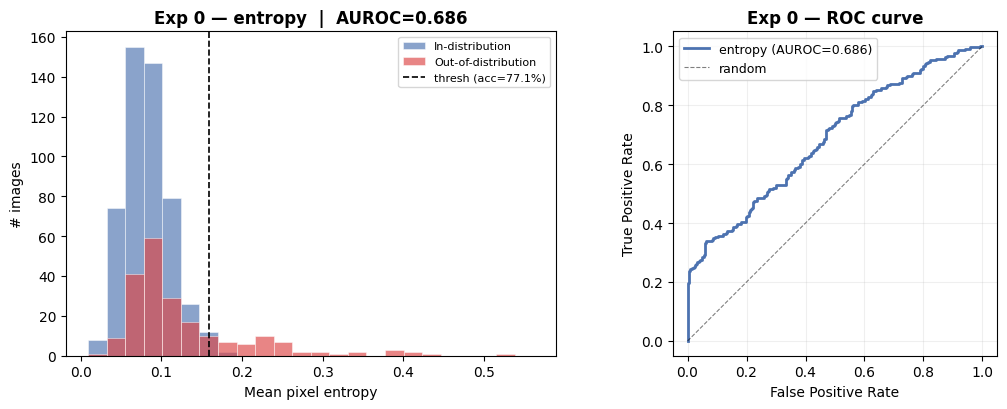

In [48]:
id_vals_e0  = np.array([r["entropy"] for r in records_e0 if r["label"] == "ID"])
ood_vals_e0 = np.array([r["entropy"] for r in records_e0 if r["label"] == "OOD"])

res_e0 = evaluate(id_vals_e0, ood_vals_e0)


print(f"{'Method':<10} {'Acc':>7} {'AUROC':>7} {'Prec':>7} {'Recall':>7} {'F1':>7} {'Thresh':>9}")
print(f"{'entropy':<10} {res_e0['accuracy']:>6.1%} {res_e0['auroc']:>6.1%} "
      f"{res_e0['precision']:>6.1%} {res_e0['recall']:>6.1%} {res_e0['f1']:>6.1%} {res_e0['threshold']:>9.4f}")
pd.DataFrame([res_e0]).to_csv(os.path.join(EXP0_DIR, "entropy_summary.csv"), index=False)

# Histogram + ROC side by side
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))

lo = min(id_vals_e0.min(), ood_vals_e0.min()) * 0.95
hi = max(id_vals_e0.max(), ood_vals_e0.max()) * 1.05
bins = np.linspace(lo, hi, 25)
axes[0].hist(id_vals_e0,  bins=bins, alpha=0.65, color="#4C72B0",
             label="In-distribution",    edgecolor="white", linewidth=0.5)
axes[0].hist(ood_vals_e0, bins=bins, alpha=0.65, color="#DD4444",
             label="Out-of-distribution", edgecolor="white", linewidth=0.5)
axes[0].axvline(res_e0["threshold"], color="black", linestyle="--", linewidth=1.2,
                label=f"thresh (acc={res_e0['accuracy']:.1%})")
axes[0].set_xlabel("Mean pixel entropy")
axes[0].set_ylabel("# images")
axes[0].set_title(f"Exp 0 — entropy  |  AUROC={res_e0['auroc']:.3f}", fontweight="bold")
axes[0].legend(fontsize=8)

labels_e0 = np.concatenate([np.zeros(len(id_vals_e0)), np.ones(len(ood_vals_e0))])
scores_e0 = np.concatenate([id_vals_e0, ood_vals_e0])
fpr, tpr, _ = roc_curve(labels_e0, scores_e0)
axes[1].plot(fpr, tpr, color="#4C72B0", linewidth=2,
             label=f"entropy (AUROC={res_e0['auroc']:.3f})")
axes[1].plot([0, 1], [0, 1], "k--", alpha=0.5, linewidth=0.8, label="random")
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].set_title("Exp 0 — ROC curve", fontweight="bold")
axes[1].legend(fontsize=9); axes[1].set_aspect("equal"); axes[1].grid(alpha=0.2)

plt.tight_layout()
plt.savefig(os.path.join(EXP0_DIR, "entropy_baseline.pdf"), dpi=300, bbox_inches="tight")
plt.show()


---
## Experiment 1 — Which aggregation metric?

For each image I get 64 GSVD ratios (indices 256..319 of the spectrum). I need to turn that into one score per image. Three obvious choices:

- **mean** — sensitive to outliers
- **median** — robust to outliers
- **max** — picks the single worst direction

Which one separates ID from OOD best?

I use `SegFormerNovice` (random-init) + `DinoExpert` here. 

In [49]:
EXP1_DIR = os.path.join(RESULTS_ROOT, "exp1_metric")
os.makedirs(EXP1_DIR, exist_ok=True)
EXP1_CSV = os.path.join(EXP1_DIR, "metric_comparison.csv")

N_RATIOS_E1  = 64
START_IDX_E1 = 256
METRICS      = ["mean", "median", "max"]


def run_exp1(force=False):
    """Runs inference for Exp 1 (or loads the cached CSV). Returns list of records."""
    if not force and os.path.exists(EXP1_CSV):
        print(f"Loading cached results from {EXP1_CSV}")
        return pd.read_csv(EXP1_CSV).to_dict("records")

    set_seed(SEED)
    novice = SegFormerNovice().to(DEVICE).eval()
    expert = DinoExpert().to(DEVICE).eval()

    records = []
    for label, folders in [("ID", ID_FOLDERS), ("OOD", OOD_FOLDERS)]:
        paths = collect_image_paths(folders)
        print(f"{label}: {len(paths)} images")
        for path in tqdm(paths, desc=label):
            try:
                img = Image.open(path).convert("RGB")
                x = preprocess(img).unsqueeze(0).to(DEVICE)
                with torch.no_grad():
                    A_feat = novice(x)
                    B_feat = expert(x, target_size=(A_feat.shape[2], A_feat.shape[3]))
                ratios = compute_gsvd_ratios(A_feat, B_feat, START_IDX_E1, N_RATIOS_E1)
                finite = ratios[np.isfinite(ratios)]
                if len(finite) == 0:
                    continue
                records.append({
                    "label":    label,
                    "filename": os.path.basename(path),
                    "mean":     float(finite.mean()),
                    "median":   float(np.median(finite)),
                    "max":      float(finite.max()),
                })
            except Exception as e:
                print(f"FAIL {os.path.basename(path)}: {e}")

    with open(EXP1_CSV, "w", newline="") as f:
        w = csv.DictWriter(f, fieldnames=["label", "filename", "mean", "median", "max"])
        w.writeheader()
        w.writerows(records)
    print(f"Saved -> {EXP1_CSV}")

    del novice, expert
    if DEVICE == "cuda":
        torch.cuda.empty_cache()
    return records


records_e1 = run_exp1()
print(f"Total records: {len(records_e1)}")

Loading cached results from results/exp1_metric/metric_comparison.csv
Total records: 713


### Evaluate each metric

In [50]:
id_recs_e1  = [r for r in records_e1 if r["label"] == "ID"]
ood_recs_e1 = [r for r in records_e1 if r["label"] == "OOD"]

summary_e1 = []
for metric in METRICS:
    id_vals  = np.array([r[metric] for r in id_recs_e1])
    ood_vals = np.array([r[metric] for r in ood_recs_e1])
    res = evaluate(id_vals, ood_vals)
    res["metric"] = metric
    summary_e1.append(res)

print(f"{'Metric':<8} {'Acc':>7} {'AUROC':>7} {'Prec':>7} {'Recall':>7} {'F1':>7}")
for r in summary_e1:
    print(f"{r['metric']:<8} {r['accuracy']:>6.1%} {r['auroc']:>6.1%} "
          f"{r['precision']:>6.1%} {r['recall']:>6.1%} {r['f1']:>6.1%}")

pd.DataFrame(summary_e1).to_csv(os.path.join(EXP1_DIR, "metric_summary.csv"), index=False)

Metric       Acc   AUROC    Prec  Recall      F1
mean      85.4%  91.2%  78.2%  70.0%  73.9%
median    86.4%  92.6%  76.5%  77.6%  77.1%
max       84.4%  89.9%  74.4%  71.9%  73.1%


### Plots, histograms and ROC curves

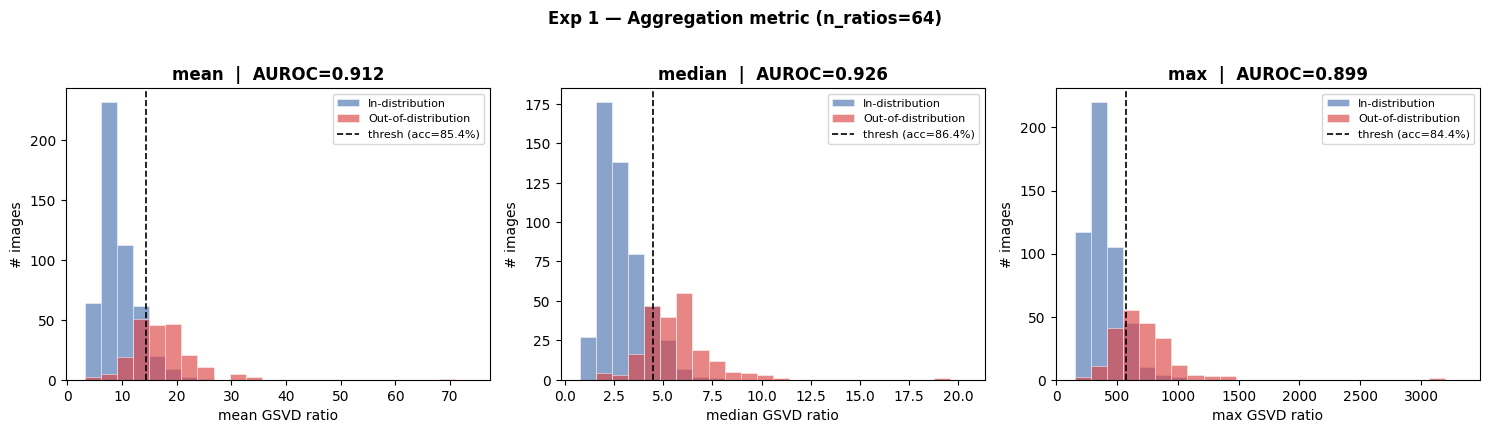

In [51]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
for ax, metric in zip(axes, METRICS):
    id_vals  = np.array([r[metric] for r in id_recs_e1])
    ood_vals = np.array([r[metric] for r in ood_recs_e1])
    row = next(r for r in summary_e1 if r["metric"] == metric)
    lo = min(id_vals.min(), ood_vals.min()) * 0.95
    hi = max(id_vals.max(), ood_vals.max()) * 1.05
    bins = np.linspace(lo, hi, 25)
    ax.hist(id_vals,  bins=bins, alpha=0.65, color="#4C72B0",
            label="In-distribution",    edgecolor="white", linewidth=0.5)
    ax.hist(ood_vals, bins=bins, alpha=0.65, color="#DD4444",
            label="Out-of-distribution", edgecolor="white", linewidth=0.5)
    ax.axvline(row["threshold"], color="black", linestyle="--", linewidth=1.2,
               label=f"thresh (acc={row['accuracy']:.1%})")
    ax.set_xlabel(f"{metric} GSVD ratio")
    ax.set_ylabel("# images")
    ax.set_title(f"{metric}  |  AUROC={row['auroc']:.3f}", fontweight="bold")
    ax.legend(fontsize=8)
fig.suptitle(f"Exp 1 — Aggregation metric (n_ratios={N_RATIOS_E1})",
             y=1.02, fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(EXP1_DIR, "histogram.pdf"), dpi=300, bbox_inches="tight")
plt.show()

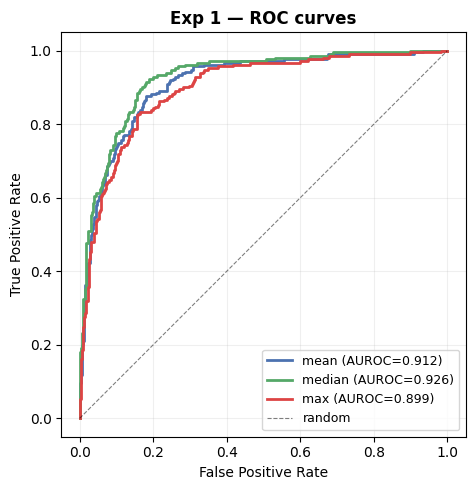

In [52]:
fig, ax = plt.subplots(figsize=(5.5, 5))
colors_e1 = {"mean": "#4C72B0", "median": "#55A868", "max": "#DD4444"}
for metric in METRICS:
    id_vals  = np.array([r[metric] for r in id_recs_e1])
    ood_vals = np.array([r[metric] for r in ood_recs_e1])
    labels = np.concatenate([np.zeros(len(id_vals)), np.ones(len(ood_vals))])
    scores = np.concatenate([id_vals, ood_vals])
    fpr, tpr, _ = roc_curve(labels, scores)
    auroc = roc_auc_score(labels, scores)
    ax.plot(fpr, tpr, color=colors_e1[metric], linewidth=2,
            label=f"{metric} (AUROC={auroc:.3f})")
ax.plot([0, 1], [0, 1], "k--", alpha=0.5, linewidth=0.8, label="random")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("Exp 1 — ROC curves", fontweight="bold")
ax.legend(fontsize=9); ax.set_aspect("equal"); ax.grid(alpha=0.2)
plt.tight_layout()
plt.savefig(os.path.join(EXP1_DIR, "roc.pdf"), dpi=300, bbox_inches="tight")
plt.show()

**Takeaway:** median wins. It's the most robust to numerical blowups when `S` has tiny denominators (which makes `C/S` explode for just one or two directions and torch the mean/max). 

---
## Experiments 2 + 3 — Novice architecture + number of ratios

Running inference on these models takes a while, so I merged Experiments 2 and 3 to speed things up. I just run each novice once, extract all 64 ratios per image, and save them to a file.

Then I just use that cached data for both experiments:
    Exp 2: Which novice architecture gives the best AUROC? (Using the median of all 64 ratios).
    Exp 3: How many ratios do we actually need? I take the saved data and slice it to the first n ratios to see how the AUROC changes. Because the numbers are already cached, this sweep takes barely any time!

The novices I'm comparing:
    Linear: Super simple 1x1 conv (only ~960 params).
    Nonlinear CNN: A basic 4-block CNN (~1.2M params).
    SegFormer-B5: The massive full encoder (~84M params).

In [53]:
EXP23_DIR = os.path.join(RESULTS_ROOT, "exp23_novice_nratios")
os.makedirs(EXP23_DIR, exist_ok=True)
EXP23_CSV = os.path.join(EXP23_DIR, "raw_ratios.csv")

NOVICE_CLASSES = {
    "Linear":         LinearNovice,
    "Nonlinear CNN":  NonlinearNovice,
    "SegFormer-B5":   SegFormerNovice,
}
MAX_RATIOS = 64   # number of GSVD ratios to save per image


def run_exp23(force=False):
    if not force and os.path.exists(EXP23_CSV):
        print(f"Loading cached {EXP23_CSV}")
        df = pd.read_csv(EXP23_CSV)
        ratio_cols = [c for c in df.columns if c.startswith("ratio_")]
        return [{
            "novice":   row["novice"],
            "label":    row["label"],
            "filename": row["filename"],
            "ratios":   row[ratio_cols].to_numpy(dtype=float),
        } for _, row in df.iterrows()]

    expert = DinoExpert().to(DEVICE).eval()
    records = []

    for novice_name, NoviceCls in NOVICE_CLASSES.items():
        print(f"\n{'='*50}\n  {novice_name}\n{'='*50}")
        set_seed(SEED)
        novice = NoviceCls().to(DEVICE).eval()
        n_params = sum(p.numel() for p in novice.parameters())
        print(f"  Params: {n_params:,}")

        for label, folders in [("ID", ID_FOLDERS), ("OOD", OOD_FOLDERS)]:
            paths = collect_image_paths(folders)
            for path in tqdm(paths, desc=f"{novice_name} / {label}"):
                try:
                    img = Image.open(path).convert("RGB")
                    x = preprocess(img).unsqueeze(0).to(DEVICE)
                    with torch.no_grad():
                        A_feat = novice(x)
                        B_feat = expert(x, target_size=(A_feat.shape[2], A_feat.shape[3]))
                    ratios = compute_gsvd_ratios(A_feat, B_feat, 256, MAX_RATIOS)
                    records.append({
                        "novice":   novice_name,
                        "label":    label,
                        "filename": os.path.basename(path),
                        "ratios":   np.asarray(ratios, dtype=float),
                    })
                except Exception as e:
                    print(f"FAIL {os.path.basename(path)}: {e}")

        del novice
        if DEVICE == "cuda":
            torch.cuda.empty_cache()

    # save as wide CSV: one ratio per column
    with open(EXP23_CSV, "w", newline="") as f:
        w = csv.writer(f)
        header = ["novice", "label", "filename"] + [f"ratio_{i+1}" for i in range(MAX_RATIOS)]
        w.writerow(header)
        for r in records:
            w.writerow([r["novice"], r["label"], r["filename"]] +
                       [f"{v:.6f}" for v in r["ratios"]])
    print(f"Saved -> {EXP23_CSV}")

    del expert
    if DEVICE == "cuda":
        torch.cuda.empty_cache()
    return records


records_e23 = run_exp23()
print(f"Total records: {len(records_e23)}")

Loading cached results/exp23_novice_nratios/raw_ratios.csv
Total records: 2139


### Experiment 2 — evaluate each novice at n_ratios = 64 (median)

In [54]:
summary_e2 = []
for novice_name, NoviceCls in NOVICE_CLASSES.items():
    sub = [r for r in records_e23 if r["novice"] == novice_name]
    id_vals  = np.array([aggregate(r["ratios"], "median") for r in sub if r["label"] == "ID"],  dtype=float)
    ood_vals = np.array([aggregate(r["ratios"], "median") for r in sub if r["label"] == "OOD"], dtype=float)
    res = evaluate(id_vals, ood_vals)
    res["novice"] = novice_name
    # count params by building a fresh instance (tiny overhead, avoids keeping models in memory)
    set_seed(SEED)
    tmp = NoviceCls()
    res["params"] = int(sum(p.numel() for p in tmp.parameters()))
    del tmp
    summary_e2.append(res)

print(f"{'Novice':<16} {'Params':>12} {'Acc':>7} {'AUROC':>7} {'F1':>7}")
for r in summary_e2:
    print(f"{r['novice']:<16} {r['params']:>12,} "
          f"{r['accuracy']:>6.1%} {r['auroc']:>6.1%} {r['f1']:>6.1%}")

pd.DataFrame(summary_e2).to_csv(os.path.join(EXP23_DIR, "novice_summary.csv"), index=False)

Novice                 Params     Acc   AUROC      F1
Linear                    960  75.0%  63.0%  42.6%
Nonlinear CNN       1,109,952  88.6%  92.0%  79.5%
SegFormer-B5       84,607,955  86.4%  92.6%  77.1%


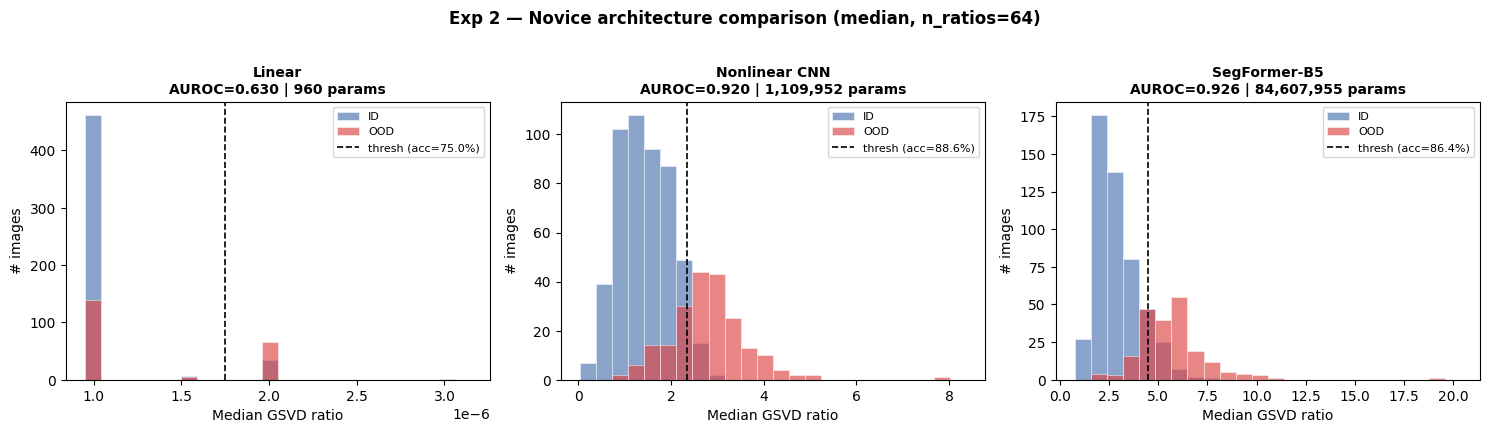

In [55]:
# Histograms per novice
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
for ax, (novice_name, _NoviceCls) in zip(axes, NOVICE_CLASSES.items()):
    sub = [r for r in records_e23 if r["novice"] == novice_name]
    id_vals  = np.array([aggregate(r["ratios"], "median") for r in sub if r["label"] == "ID"],  dtype=float)
    ood_vals = np.array([aggregate(r["ratios"], "median") for r in sub if r["label"] == "OOD"], dtype=float)
    id_vals  = id_vals[np.isfinite(id_vals)]
    ood_vals = ood_vals[np.isfinite(ood_vals)]
    row = next(r for r in summary_e2 if r["novice"] == novice_name)
    lo = min(id_vals.min(), ood_vals.min()) * 0.95
    hi = max(id_vals.max(), ood_vals.max()) * 1.05
    bins = np.linspace(lo, hi, 25)
    ax.hist(id_vals,  bins=bins, alpha=0.65, color="#4C72B0", label="ID",  edgecolor="white", linewidth=0.5)
    ax.hist(ood_vals, bins=bins, alpha=0.65, color="#DD4444", label="OOD", edgecolor="white", linewidth=0.5)
    ax.axvline(row["threshold"], color="black", linestyle="--", linewidth=1.2,
               label=f"thresh (acc={row['accuracy']:.1%})")
    ax.set_xlabel("Median GSVD ratio")
    ax.set_ylabel("# images")
    ax.set_title(f"{novice_name}\nAUROC={row['auroc']:.3f} | {row['params']:,} params",
                 fontweight="bold", fontsize=10)
    ax.legend(fontsize=8)
fig.suptitle("Exp 2 — Novice architecture comparison (median, n_ratios=64)",
             y=1.02, fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(EXP23_DIR, "exp2_histograms.pdf"), dpi=300, bbox_inches="tight")
plt.show()

### Experiment 3 — sweep n_ratios on the two best novices

I drop the `Linear` novice and sweep `n_ratios ∈ {2, 5, 10, ...}` on the two better ones. For each value of `n`, I just take the first `n` saved ratios per image and take the median. Cheap.

In [56]:
N_RATIOS_LIST = [2, 5, 10, 15, 20, 25, 30, 40, 50, 64]
BEST_NOVICES  = ["Nonlinear CNN", "SegFormer-B5"]

sweep_rows = []
for novice_name in BEST_NOVICES:
    sub = [r for r in records_e23 if r["novice"] == novice_name]
    for n in N_RATIOS_LIST:
        id_scores, ood_scores = [], []
        for r in sub:
            s = aggregate(r["ratios"][:n], "median")
            if s is None:
                continue
            (id_scores if r["label"] == "ID" else ood_scores).append(s)
        res = evaluate(np.asarray(id_scores), np.asarray(ood_scores))
        res["novice"]   = novice_name
        res["n_ratios"] = n
        sweep_rows.append(res)

sweep_df = pd.DataFrame(sweep_rows)[
    ["novice", "n_ratios", "accuracy", "auroc", "precision", "recall", "f1", "threshold"]
]
sweep_df.to_csv(os.path.join(EXP23_DIR, "nratios_sweep.csv"), index=False)
sweep_df

,novice,n_ratios,accuracy,auroc,precision,recall,f1,threshold
0,Nonlinear CNN,2,0.845722,0.897643,0.777778,0.666667,0.717949,200.188317
1,Nonlinear CNN,5,0.887798,0.941986,0.818627,0.795238,0.806763,7.537540
2,Nonlinear CNN,10,0.886396,0.942545,0.797235,0.823810,0.810304,6.499405
3,Nonlinear CNN,15,0.889201,0.942393,0.861878,0.742857,0.797954,6.058091
4,Nonlinear CNN,20,0.894811,0.940500,0.853403,0.776190,0.812968,5.438541
5,Nonlinear CNN,25,0.889201,0.939127,0.861878,0.742857,0.797954,5.035329
6,Nonlinear CNN,30,0.892006,0.940822,0.837563,0.785714,0.810811,4.461555
7,Nonlinear CNN,40,0.887798,0.936278,0.821782,0.790476,0.805825,3.693521
8,Nonlinear CNN,50,0.887798,0.931648,0.849462,0.752381,0.797980,3.110438
9,Nonlinear CNN,64,0.886396,0.919966,0.848649,0.747619,0.794937,2.350076


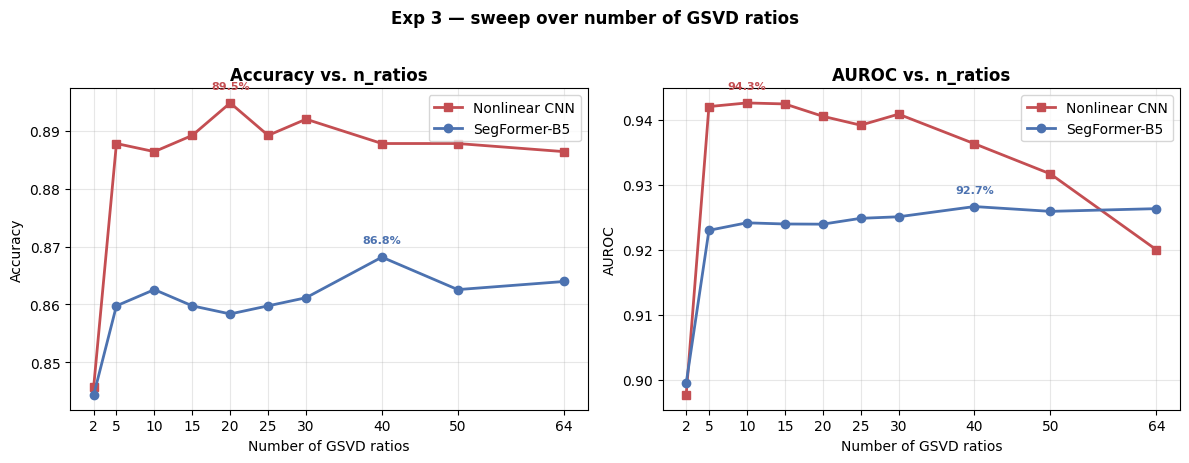

In [57]:
# Plot accuracy & AUROC vs n_ratios
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
style = {"Nonlinear CNN": dict(color="#C44E52", marker="s"),
         "SegFormer-B5":   dict(color="#4C72B0", marker="o")}
for ax, key, ylabel in zip(axes, ["accuracy", "auroc"], ["Accuracy", "AUROC"]):
    for novice_name in BEST_NOVICES:
        rows = [r for r in sweep_rows if r["novice"] == novice_name]
        ns = [r["n_ratios"] for r in rows]
        vs = [r[key] for r in rows]
        ax.plot(ns, vs, linewidth=2, markersize=6, label=novice_name, **style[novice_name])
        best_idx = int(np.argmax(vs))
        ax.annotate(f"{vs[best_idx]:.1%}",
                    xy=(ns[best_idx], vs[best_idx]),
                    textcoords="offset points", xytext=(0, 10),
                    fontsize=8, ha="center", fontweight="bold",
                    color=style[novice_name]["color"])
    ax.set_xlabel("Number of GSVD ratios")
    ax.set_ylabel(ylabel)
    ax.set_title(f"{ylabel} vs. n_ratios", fontweight="bold")
    ax.set_xticks(N_RATIOS_LIST)
    ax.legend(); ax.grid(alpha=0.3)
fig.suptitle("Exp 3 — sweep over number of GSVD ratios", y=1.02, fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(EXP23_DIR, "nratios_sweep.pdf"), dpi=300, bbox_inches="tight")
plt.show()

Takeaway from Exp 2 + 3: 
- Linear novice is too simple, no nonlinearity means the score barely separates ID from OOD.
- Nonlinear CNN and SegFormer perform similarly, but the tiny CNN is way smaller in parameters. 
- AUROC saturates quickly as `n_ratios` grows, adding more just injects noise from higher-index ratios.

---
## Experiment 4 — What if the expert is a pretrained SegFormer instead of DINOv3?

Does the GSVD trick need a **generalist** expert like DINOv3, or can it lean on a **task-specialist** like a SegFormer pretrained on Cityscapes?

Setup changes:
- Expert feature dim: 768 → 320 (SegFormer's `hidden_states[2]`).
- To keep a similar expert:novice dim ratio I drop the novice to 128-dim.
- With a 320-dim column space, I now have at most 320 generalized svs. I pick `start_idx=100` and the max slice is 28 ratios (roughly the same "fraction from the tail" I used with DINOv3).

In [58]:
NOVICE_FEAT_DIM_E4 = 128

class NonlinearNoviceE4(nn.Module):
    """Slimmer CNN for Exp 4 — outputs 128-dim features."""
    def __init__(self, in_channels=3, feat_dim=NOVICE_FEAT_DIM_E4):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_channels, 32, 3, stride=2, padding=1),
            nn.BatchNorm2d(32), nn.ReLU(inplace=True),
            nn.Conv2d(32, 64, 3, stride=2, padding=1),
            nn.BatchNorm2d(64), nn.ReLU(inplace=True),
            nn.Conv2d(64, 96, 3, stride=2, padding=1),
            nn.BatchNorm2d(96), nn.ReLU(inplace=True),
            nn.Conv2d(96, feat_dim, 3, stride=2, padding=1),
            nn.BatchNorm2d(feat_dim), nn.ReLU(inplace=True),
        )
    def forward(self, x):
        return self.net(x)

class SegFormerNoviceE4(nn.Module):
    """Random SegFormer novice that returns hidden_states[1] (128-dim)
    and downsamples to 32x32 to match the expert's spatial size."""
    def __init__(self):
        super().__init__()
        self.segformer = SegformerForSemanticSegmentation(_segformer_b5_config())
    def forward(self, x):
        out = self.segformer(pixel_values=x, output_hidden_states=True)
        feat = out.hidden_states[1]              # (1, 128, H/8, W/8)
        return F.interpolate(feat, size=FEAT_SIZE, mode="bilinear", align_corners=False)

In [59]:
EXP4_DIR = os.path.join(RESULTS_ROOT, "exp4_segformer_expert")
os.makedirs(EXP4_DIR, exist_ok=True)
EXP4_CSV = os.path.join(EXP4_DIR, "raw_ratios.csv")

START_IDX_E4  = 100
MAX_RATIOS_E4 = 28
N_RATIOS_LIST_E4 = [2, 5, 8, 10, 15, 20, 25, 28]

NOVICE_CLASSES_E4 = {
    "Nonlinear CNN":        NonlinearNoviceE4,
    "SegFormer-B5 (rand)":  SegFormerNoviceE4,
}


def run_exp4(force=False):
    if not force and os.path.exists(EXP4_CSV):
        print(f"Loading cached {EXP4_CSV}")
        df = pd.read_csv(EXP4_CSV)
        ratio_cols = [c for c in df.columns if c.startswith("ratio_")]
        return [{
            "novice":   row["novice"],
            "label":    row["label"],
            "filename": row["filename"],
            "ratios":   row[ratio_cols].to_numpy(dtype=float),
        } for _, row in df.iterrows()]

    expert = SegFormerExpert().to(DEVICE).eval()
    records = []

    for novice_name, NoviceCls in NOVICE_CLASSES_E4.items():
        print(f"\n{'='*50}\n  {novice_name}\n{'='*50}")
        set_seed(SEED)
        novice = NoviceCls().to(DEVICE).eval()
        print(f"  Params: {sum(p.numel() for p in novice.parameters()):,}")

        for label, folders in [("ID", ID_FOLDERS), ("OOD", OOD_FOLDERS)]:
            paths = collect_image_paths(folders)
            for path in tqdm(paths, desc=f"{novice_name} / {label}"):
                try:
                    img = Image.open(path).convert("RGB")
                    x = preprocess(img).unsqueeze(0).to(DEVICE)
                    with torch.no_grad():
                        A_feat = novice(x)          # (1, 128, 32, 32)
                        B_feat = expert(x)          # (1, 320, 32, 32)
                    ratios = compute_gsvd_ratios(A_feat, B_feat, START_IDX_E4, MAX_RATIOS_E4)
                    records.append({
                        "novice":   novice_name,
                        "label":    label,
                        "filename": os.path.basename(path),
                        "ratios":   np.asarray(ratios, dtype=float),
                    })
                except Exception as e:
                    print(f"FAIL {os.path.basename(path)}: {e}")
        del novice
        if DEVICE == "cuda":
            torch.cuda.empty_cache()

    with open(EXP4_CSV, "w", newline="") as f:
        w = csv.writer(f)
        w.writerow(["novice", "label", "filename"] +
                   [f"ratio_{i+1}" for i in range(MAX_RATIOS_E4)])
        for r in records:
            w.writerow([r["novice"], r["label"], r["filename"]] +
                       [f"{v:.6f}" for v in r["ratios"]])
    print(f"Saved -> {EXP4_CSV}")
    del expert
    if DEVICE == "cuda":
        torch.cuda.empty_cache()
    return records


records_e4 = run_exp4()
print(f"Total records: {len(records_e4)}")

Loading cached results/exp4_segformer_expert/raw_ratios.csv
Total records: 1426


In [60]:
# Sweep n_ratios with the new expert
sweep_rows_e4 = []
for novice_name in NOVICE_CLASSES_E4:
    sub = [r for r in records_e4 if r["novice"] == novice_name]
    for n in N_RATIOS_LIST_E4:
        id_scores, ood_scores = [], []
        for r in sub:
            s = aggregate(r["ratios"][:n], "median")
            if s is None:
                continue
            (id_scores if r["label"] == "ID" else ood_scores).append(s)
        res = evaluate(np.asarray(id_scores), np.asarray(ood_scores))
        res["novice"]   = novice_name
        res["n_ratios"] = n
        sweep_rows_e4.append(res)

sweep_df_e4 = pd.DataFrame(sweep_rows_e4)[
    ["novice", "n_ratios", "accuracy", "auroc", "precision", "recall", "f1", "threshold"]
]
sweep_df_e4.to_csv(os.path.join(EXP4_DIR, "nratios_sweep.csv"), index=False)
sweep_df_e4

,novice,n_ratios,accuracy,auroc,precision,recall,f1,threshold
0,Nonlinear CNN,2,0.571227,0.474856,0.263682,0.253589,0.258537,6.219493e+07
1,Nonlinear CNN,5,0.598878,0.486041,0.273810,0.219048,0.243386,5.728100e+07
2,Nonlinear CNN,8,0.625526,0.483097,0.238532,0.123810,0.163009,6.219493e+07
3,Nonlinear CNN,10,0.652174,0.469914,0.273810,0.109524,0.156463,6.219493e+07
4,Nonlinear CNN,15,0.685835,0.490254,0.354167,0.080952,0.131783,5.728100e+07
5,Nonlinear CNN,20,0.704067,0.499517,0.470588,0.038095,0.070485,6.219493e+07
6,Nonlinear CNN,25,0.702665,0.497619,0.250000,0.004762,0.009346,5.728100e+07
7,Nonlinear CNN,28,0.704067,0.500814,0.000000,0.000000,0.000000,6.219493e+07
8,SegFormer-B5 (rand),2,0.596317,0.489491,0.259259,0.202899,0.227642,6.219493e+07
9,SegFormer-B5 (rand),5,0.616901,0.496519,0.276596,0.186603,0.222857,5.728100e+07


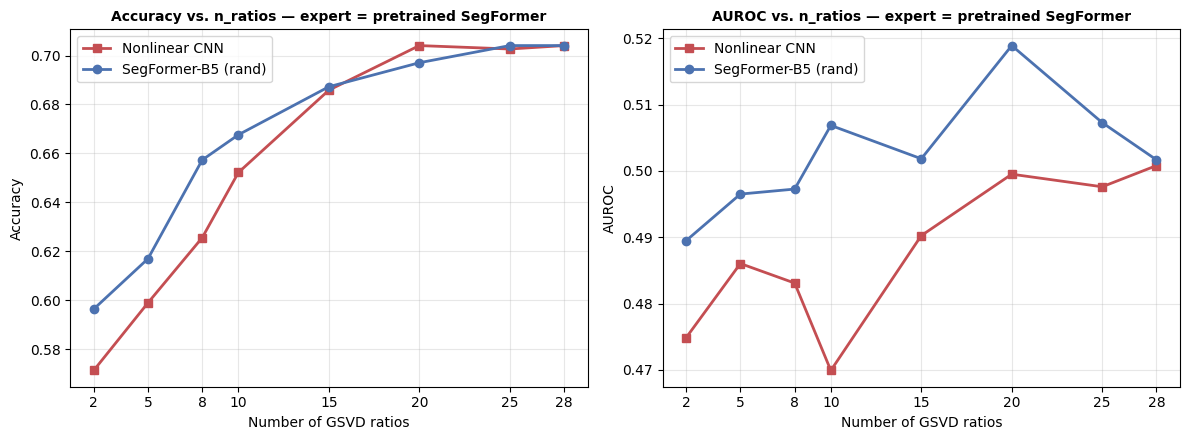

In [61]:
# Plot
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
style_e4 = {"Nonlinear CNN":       dict(color="#C44E52", marker="s"),
            "SegFormer-B5 (rand)": dict(color="#4C72B0", marker="o")}
for ax, key, ylabel in zip(axes, ["accuracy", "auroc"], ["Accuracy", "AUROC"]):
    for novice_name in NOVICE_CLASSES_E4:
        rows = [r for r in sweep_rows_e4 if r["novice"] == novice_name]
        ns = [r["n_ratios"] for r in rows]
        vs = [r[key] for r in rows]
        ax.plot(ns, vs, linewidth=2, markersize=6, label=novice_name, **style_e4[novice_name])
    ax.set_xlabel("Number of GSVD ratios")
    ax.set_ylabel(ylabel)
    ax.set_title(f"{ylabel} vs. n_ratios — expert = pretrained SegFormer",
                 fontweight="bold", fontsize=10)
    ax.set_xticks(N_RATIOS_LIST_E4)
    ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(EXP4_DIR, "nratios_sweep.pdf"), dpi=300, bbox_inches="tight")
plt.show()

**Takeaway:** The GSVD signal OOD method seams to benefit from a genralist expert.

---
## Best model: final configuration & threshold check

Okay so from the ablations the winning combo is:
- **Expert:** DINOv3 ViT-B/16
- **Novice:** Nonlinear CNN 
- **Aggregation:** median
- **Window:** leading `n=10` ratios

The sweep gave threshold ≈ 6.50 as the balanced-accuracy optimum for this config (AUROC = 0.9425, bal. acc. = 0.886). That feels kind of low to me though — looking at the SegFormer-rand novice at `n=10` the optimal threshold is ~10.00, which makes me wonder if 6.5 is overfitting to the specific spread of this novice on the val mix.

So below I:
1. Re-use the ratios already saved in `exp23/raw_ratios.csv` (no need to recompute).
2. Build the per-image score = `median(ratios[:10])` for the Nonlinear CNN rows only.
3. Plot the ID vs OOD histogram with **both** thresholds (6 and 10) marked, so we can
   eyeball whether 10 is actually closer to the natural valley between the two modes.
4. Report balanced acc / precision / recall / F1 at both thresholds side-by-side.

That way when I submit to the server I can pick the threshold that generalises, not
just the one that happens to max local bal. acc.

N images: 713  |  ID: 503  OOD: 210
Score range: [1.081, 20.660]   AUROC: 0.9425


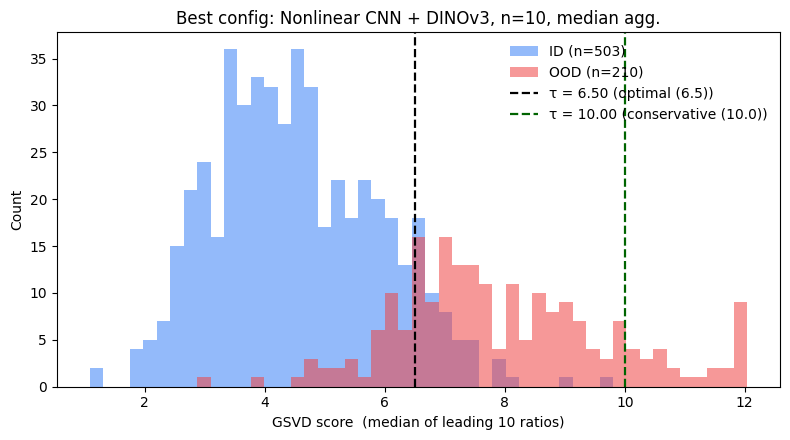

In [62]:
# =============================================================
# Best config histogram + threshold comparison
# Reuses ratios saved by run_exp23() — no recomputation needed.
# =============================================================
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import (balanced_accuracy_score, precision_score,
                             recall_score, f1_score, roc_auc_score)

BEST_DIR  = os.path.join(RESULTS_ROOT, "best_model_nonlinear_dinov3")
os.makedirs(BEST_DIR, exist_ok=True)

BEST_NOVICE   = "Nonlinear CNN"
N_RATIOS_BEST = 10                # A3 winner
AGG           = np.median         # A1 winner
THRESHOLDS    = {"optimal (6.5)": 6.50,
                 "conservative (10.0)": 10.00}

# Load ratios from Exp 2/3 CSV
df = pd.read_csv(EXP23_CSV)
df = df[df["novice"] == BEST_NOVICE].reset_index(drop=True)
ratio_cols = [c for c in df.columns if c.startswith("ratio_")]

# Build GSVD score using the best config (median of leading 10 ratios)
ratios_mat = df[ratio_cols].to_numpy(dtype=float)          # (N, 64)
scores     = AGG(ratios_mat[:, :N_RATIOS_BEST], axis=1)    # (N,)
y_true     = (df["label"].values == "OOD").astype(int)     # 1 = OOD

print(f"N images: {len(scores)}  |  ID: {(y_true==0).sum()}  OOD: {(y_true==1).sum()}")
print(f"Score range: [{scores.min():.3f}, {scores.max():.3f}]   "
      f"AUROC: {roc_auc_score(y_true, scores):.4f}")

# Histogram of scores by true label
id_scores  = scores[y_true == 0]
ood_scores = scores[y_true == 1]

# clip for visualisation
vis_clip = np.percentile(scores, 99)
bins = np.linspace(scores.min(), vis_clip, 50)

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.hist(np.clip(id_scores,  None, vis_clip), bins=bins,
        alpha=0.55, label=f"ID (n={len(id_scores)})",  color="#3b82f6")
ax.hist(np.clip(ood_scores, None, vis_clip), bins=bins,
        alpha=0.55, label=f"OOD (n={len(ood_scores)})", color="#ef4444")

colors = {"optimal (6.5)": "black", "conservative (10.0)": "darkgreen"}
for name, t in THRESHOLDS.items():
    ax.axvline(t, color=colors[name], linestyle="--", linewidth=1.6,
               label=f"τ = {t:.2f} ({name})")

ax.set_xlabel(f"GSVD score  (median of leading {N_RATIOS_BEST} ratios)")
ax.set_ylabel("Count")
ax.set_title(f"Best config: {BEST_NOVICE} + DINOv3, n={N_RATIOS_BEST}, median agg.")
ax.legend(frameon=False)
fig.tight_layout()
fig.savefig(os.path.join(BEST_DIR, "score_histogram.pdf"), bbox_inches="tight")
fig.savefig(os.path.join(BEST_DIR, "score_histogram.png"), dpi=150, bbox_inches="tight")
plt.show()


In [63]:
# Save the weights of this config model for server submission
set_seed(1)
calib_novice = NonlinearNovice().to(DEVICE).eval()

weights_dir = "../weights"
os.makedirs(weights_dir, exist_ok=True)

save_path = os.path.join(weights_dir, "novice_nonlinear_seed1.pt")
torch.save(calib_novice.state_dict(), save_path)

print("Saved novice weights:", sum(p.numel() for p in calib_novice.parameters()), "params")

Saved novice weights: 1109952 params


---
## Visualising the GSVD subspace

Before the robustness experiment I wanted to actually *look* at what the GSVD is picking up — not just histograms of scores. For one ID image and one OOD image I:

1. Compute the GSVD between novice (A) and expert (B) features.
2. Take `k=2` columns of `U` and `V` starting at index `256` (the same tail window used for scoring).
3. Use DEIM (Discrete Empirical Interpolation) on those columns to find the `k` most informative channel indices of `A_norm` and `B_norm`.
4. Reshape each picked channel (length `HW = 1024`) to a `32×32` feature map and plot it next to the input image.

If the GSVD tail really contains useful info, the picked channels should look different on the OOD image than on the ID image — ideally lighting up on the anomaly.


/var/folders/tm/q1wxwwvs1rz6rmj0tfg5nbsh0000gn/T/ipykernel_28097/2882769191.py:20: RuntimeWarning: divide by zero encountered in divide
  return C / S
/var/folders/tm/q1wxwwvs1rz6rmj0tfg5nbsh0000gn/T/ipykernel_28097/2882769191.py:34: RuntimeWarning: invalid value encountered in subtract
  diff = np.abs(np.log(gs_ood + 1e-12) - np.log(gs_id + 1e-12))


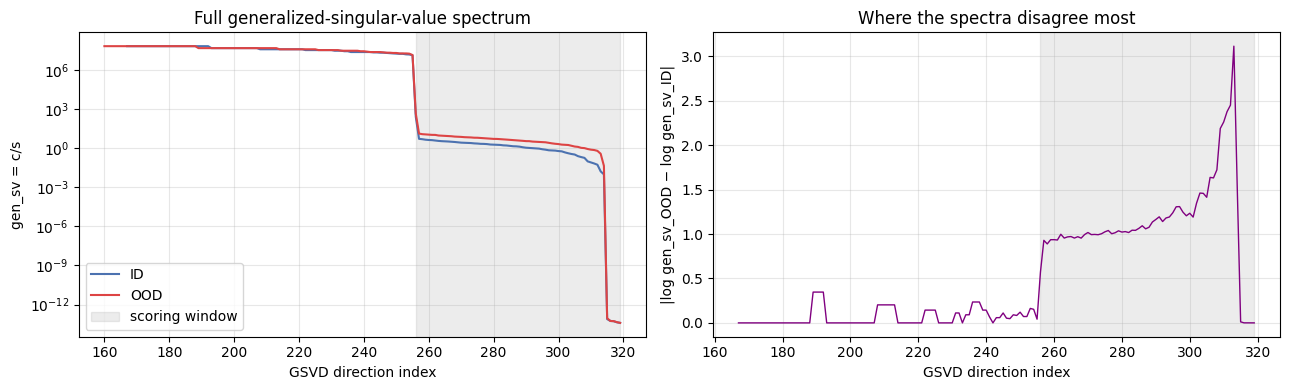

Peak disagreement index: 0  (score window: 256–319)
Using start_idx = 0 for visualization


/var/folders/tm/q1wxwwvs1rz6rmj0tfg5nbsh0000gn/T/ipykernel_28097/2882769191.py:49: RuntimeWarning: invalid value encountered in subtract
  diff = np.abs(np.log(gs_ood + 1e-12) - np.log(gs_id + 1e-12))


In [76]:
# --- Spectrum comparison: where do ID and OOD actually differ? ---
id_example  = collect_image_paths(ID_FOLDERS)[0]
ood_example = collect_image_paths(OOD_FOLDERS)[100]

set_seed(SEED)
novice = NonlinearNovice().to(DEVICE).eval()
expert = DinoExpert().to(DEVICE).eval()

def gen_sv_of(path):
    img = Image.open(path).convert("RGB")
    x = preprocess(img).unsqueeze(0).to(DEVICE)
    with torch.no_grad():
        A_feat = novice(x)
        B_feat = expert(x, target_size=(A_feat.shape[2], A_feat.shape[3]))
    A = A_feat.squeeze(0).flatten(1).T
    B = B_feat.squeeze(0).flatten(1).T
    A_norm = F.normalize(A, dim=1).T.cpu().numpy()
    B_norm = F.normalize(B, dim=1).T.cpu().numpy()
    _, _, _, C, S = gsvd0(A_norm, B_norm)
    return C / S

gs_id  = gen_sv_of(id_example)
gs_ood = gen_sv_of(ood_example)

# Plot spectra + their difference
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].semilogy(gs_id,  label="ID",  color="#4C72B0", linewidth=1.5)
axes[0].semilogy(gs_ood, label="OOD", color="#DD4444", linewidth=1.5)
axes[0].axvspan(256, 319, alpha=0.15, color="gray", label="scoring window")
axes[0].set_xlabel("GSVD direction index"); axes[0].set_ylabel("gen_sv = c/s")
axes[0].set_title("Full generalized-singular-value spectrum")
axes[0].legend(); axes[0].grid(alpha=0.3)

diff = np.abs(np.log(gs_ood + 1e-12) - np.log(gs_id + 1e-12))
axes[1].plot(diff, color="purple", linewidth=1)
axes[1].axvspan(256, 319, alpha=0.15, color="gray")
axes[1].set_xlabel("GSVD direction index")
axes[1].set_ylabel("|log gen_sv_OOD − log gen_sv_ID|")
axes[1].set_title("Where the spectra disagree most")
axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

# Peak divergence index — use this to pick viz indices
peak_idx = int(np.argmax(diff))
print(f"Peak disagreement index: {peak_idx}  (score window: 256–319)")



diff = np.abs(np.log(gs_ood + 1e-12) - np.log(gs_id + 1e-12))
peak_idx = int(np.argmax(diff[:-3]))   # skip floor-collapse tail
print(f"Using start_idx = {peak_idx} for visualization")

start_idx = peak_idx

ID example : tubingen_000000_000019_leftImg8bit.png
OOD example: airplane0000.jpg


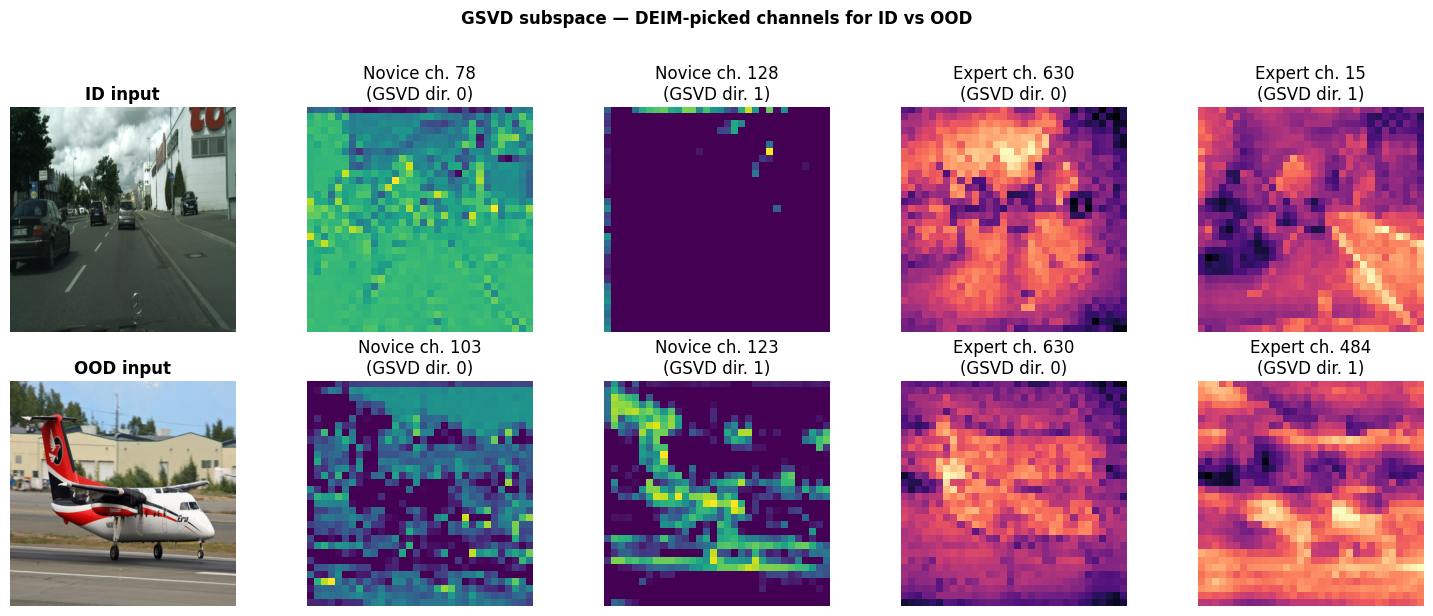

In [80]:
from numpy.linalg import solve

def deim(U, k):
    """Discrete Empirical Interpolation Method — pick k row indices of U (shape (m, k))."""
    indices = [int(np.argmax(np.abs(U[:, 0])))]
    for j in range(1, k):
        c = solve(U[np.ix_(indices, range(j))], U[indices, j])
        r = U[:, j] - U[:, :j] @ c
        indices.append(int(np.argmax(np.abs(r))))
    return indices


def feats_and_gsvd(path, novice, expert):
    """Run novice + expert on one image and return GSVD pieces."""
    img = Image.open(path).convert("RGB")
    x = preprocess(img).unsqueeze(0).to(DEVICE)
    with torch.no_grad():
        A_feat = novice(x)
        B_feat = expert(x, target_size=(A_feat.shape[2], A_feat.shape[3]))
    A = A_feat.squeeze(0).flatten(1).T                    # (HW, C_A)
    B = B_feat.squeeze(0).flatten(1).T                    # (HW, C_B)
    A_norm = F.normalize(A, dim=1).T.cpu().numpy()        # (C_A, HW)
    B_norm = F.normalize(B, dim=1).T.cpu().numpy()        # (C_B, HW)
    U, V, _, C, S = gsvd0(A_norm, B_norm)
    return img, A_norm, B_norm, U, V


def to_map(vec):
    """Flip sign for consistent coloring, then reshape to the 32x32 grid."""
    if vec.sum() < 0:
        vec = -vec
    return vec.reshape(32, 32)


# Pick one ID and one OOD image
id_example  = collect_image_paths(ID_FOLDERS)[0]
ood_example = collect_image_paths(OOD_FOLDERS)[100]
print("ID example :", os.path.basename(id_example))
print("OOD example:", os.path.basename(ood_example))

set_seed(SEED)
novice = NonlinearNovice().to(DEVICE).eval()
expert = DinoExpert().to(DEVICE).eval()

start_idx = peak_idx
k = 2

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
for row, (label, path) in enumerate([("ID", id_example), ("OOD", ood_example)]):
    img, A_norm, B_norm, U, V = feats_and_gsvd(path, novice, expert)

    U_sel = U[:, start_idx:start_idx + k]
    V_sel = V[:, start_idx:start_idx + k]
    indU = deim(U_sel, k)
    indV = deim(V_sel, k)
    Ap = A_norm[indU, :]
    Bp = B_norm[indV, :]

    # Column 0: input image
    axes[row, 0].imshow(img.resize((512, 512)))
    axes[row, 0].set_title(f"{label} input", fontweight="bold")
    axes[row, 0].axis("off")

    # Columns 1-2: novice-side picked channels (A)
    for j in range(k):
        axes[row, 1 + j].imshow(to_map(Ap[j]), cmap="viridis")
        axes[row, 1 + j].set_title(f"Novice ch. {indU[j]}\n(GSVD dir. {start_idx + j})")
        axes[row, 1 + j].axis("off")

    # Columns 3-4: expert-side picked channels (B)
    for j in range(k):
        axes[row, 3 + j].imshow(to_map(Bp[j]), cmap="magma")
        axes[row, 3 + j].set_title(f"Expert ch. {indV[j]}\n(GSVD dir. {start_idx + j})")
        axes[row, 3 + j].axis("off")

fig.suptitle("GSVD subspace — DEIM-picked channels for ID vs OOD", y=1.02, fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(BEST_DIR, "gsvd_feature_viz.pdf"), dpi=300, bbox_inches="tight")
plt.show()

del novice, expert
if DEVICE == "cuda":
    torch.cuda.empty_cache()


**What to look for:** on the ID image, the novice and expert picked channels should look roughly similar (both models "agree" on the scene structure). On the OOD image, the expert's picked channel should light up around the anomalous object (since that's the region where the expert's structured features differ most from the random-like novice) — which is exactly what pushes the GSVD tail ratios up and drives the OOD score.

---
## Experiment 5 — Is it really detecting OOD, or just domain shift / brightness?

This is the hardest question. The score might work on Fishyscapes + AnomalyTrack just because those images look *different* (brightness, color, paste artifacts) from Cityscapes — not because they contain *anomalies*.

To disentangle that I add two more groups:

- **DS (synthetic)** — Cityscapes images with 5 augmentations (dark, bright, blur, color cast, fog). Same *content* as ID, different *appearance*. Pure covariate shift.
- **DS_real** — BDD100K images. Real driving-scene covariate shift (different country, camera, labeling), no anomalies.

Ideal behavior of the score:
- Goes up on OOD (that's the job).
- Stays roughly at the ID level on DS and DS_real (robust to covariate shift).

I also scatter score vs. mean image luminance — if they correlate strongly (|r| > 0.6) the score has collapsed into a brightness detector.

Setup: `NonlinearNovice` (from Exp 2/3) + `DinoExpert`, **n_ratios = 10** (best from Exp 3), median.

In [64]:
import os, glob, csv, random

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F

import matplotlib.pyplot as plt
from PIL import Image, ImageFilter
from sklearn.metrics import roc_auc_score, roc_curve
from tqdm.auto import tqdm
import pandas as pd

import timm
from transformers import SegformerForSemanticSegmentation, SegformerConfig
from torchvision.transforms.v2 import (
    Compose, ToImage, Resize, ToDtype, Normalize, InterpolationMode,
)

# Set up matplotlib parameters for plotting
plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["figure.dpi"] = 100

In [65]:
class Augs:
    """5 synthetic domain shift augmentations"""
    @staticmethod
    def dark(img):
        arr = np.asarray(img, dtype=np.float32) * 0.35
        arr[..., 2] = np.clip(arr[..., 2] * 1.15, 0, 255)
        return Image.fromarray(np.clip(arr, 0, 255).astype(np.uint8))
    @staticmethod
    def bright(img):
        arr = np.clip(np.asarray(img, dtype=np.float32) * 1.3 + 15, 0, 255)
        return Image.fromarray(arr.astype(np.uint8))
    @staticmethod
    def blur(img):
        return img.filter(ImageFilter.GaussianBlur(radius=4))
    @staticmethod
    def color_cast(img):
        arr = np.asarray(img, dtype=np.float32)
        arr[..., 0] = np.clip(arr[..., 0] * 1.25, 0, 255)
        arr[..., 2] = np.clip(arr[..., 2] * 0.75, 0, 255)
        return Image.fromarray(arr.astype(np.uint8))
    @staticmethod
    def fog(img):
        img = img.filter(ImageFilter.GaussianBlur(radius=2))
        arr = np.asarray(img, dtype=np.float32) * 0.55 + 180.0 * 0.45
        return Image.fromarray(np.clip(arr, 0, 255).astype(np.uint8))

AUGS = {
    "dark":       Augs.dark,
    "bright":     Augs.bright,
    "blur":       Augs.blur,
    "color_cast": Augs.color_cast,
    "fog":        Augs.fog,
}

In [66]:
EXP5_DIR = os.path.join(RESULTS_ROOT, "exp5_domain_shift")
os.makedirs(EXP5_DIR, exist_ok=True)
EXP5_CSV = os.path.join(EXP5_DIR, "scores.csv")

N_RATIOS_E5 = 10   # best value from Exp 3 sweep

def image_luminance(pil_img):
    return float(np.asarray(pil_img.convert("L"), dtype=np.float32).mean())

def ood_subgroup(path):
    p = path.lower()
    if "fishyscapes" in p: return "fishyscapes"
    if "anomaly" in p:     return "anomalytrack"
    return "unknown"

def score_image(img, novice, expert):
    x = preprocess(img).unsqueeze(0).to(DEVICE)
    with torch.no_grad():
        A_feat = novice(x)
        B_feat = expert(x, target_size=(A_feat.shape[2], A_feat.shape[3]))
    ratios = compute_gsvd_ratios(A_feat, B_feat, 256, N_RATIOS_E5)
    return aggregate(ratios, "median")


def run_exp5(force=False):
    if not force and os.path.exists(EXP5_CSV):
        print(f"Loading cached {EXP5_CSV}")
        return pd.read_csv(EXP5_CSV).to_dict("records")

    set_seed(SEED)
    novice = NonlinearNovice().to(DEVICE).eval()
    expert = DinoExpert().to(DEVICE).eval()

    records = []
    id_paths      = collect_image_paths(ID_FOLDERS)
    ood_paths     = collect_image_paths(OOD_FOLDERS)
    ds_real_paths = collect_image_paths(DS_REAL_FOLDERS)

    print(f"  ID:       {len(id_paths)}")
    print(f"  OOD:      {len(ood_paths)}")
    print(f"  DS_real:  {len(ds_real_paths)}")
    print(f"  DS_synth: {len(id_paths)} x {len(AUGS)} = {len(id_paths)*len(AUGS)}")

    # --- ID clean ---
    for path in tqdm(id_paths, desc="ID"):
        img = Image.open(path).convert("RGB")
        s = score_image(img, novice, expert)
        if s is None: continue
        records.append({"group": "ID", "subgroup": "none",
                        "filename": os.path.basename(path),
                        "score": s, "luminance": image_luminance(img)})

    # --- DS synthetic ---
    for aug_name, aug_fn in AUGS.items():
        for path in tqdm(id_paths, desc=f"DS/{aug_name}"):
            img = Image.open(path).convert("RGB")
            img_aug = aug_fn(img)
            s = score_image(img_aug, novice, expert)
            if s is None: continue
            records.append({"group": "DS", "subgroup": aug_name,
                            "filename": os.path.basename(path),
                            "score": s, "luminance": image_luminance(img_aug)})

    # --- DS_real (BDD100K) ---
    for path in tqdm(ds_real_paths, desc="DS_real"):
        img = Image.open(path).convert("RGB")
        s = score_image(img, novice, expert)
        if s is None: continue
        records.append({"group": "DS_real", "subgroup": "bdd100k",
                        "filename": os.path.basename(path),
                        "score": s, "luminance": image_luminance(img)})

    # --- OOD (tagged by dataset) ---
    for path in tqdm(ood_paths, desc="OOD"):
        img = Image.open(path).convert("RGB")
        s = score_image(img, novice, expert)
        if s is None: continue
        records.append({"group": "OOD", "subgroup": ood_subgroup(path),
                        "filename": os.path.basename(path),
                        "score": s, "luminance": image_luminance(img)})

    with open(EXP5_CSV, "w", newline="") as f:
        w = csv.DictWriter(f, fieldnames=["group", "subgroup", "filename", "score", "luminance"])
        w.writeheader(); w.writerows(records)
    print(f"Saved -> {EXP5_CSV}")

    del novice, expert
    if DEVICE == "cuda":
        torch.cuda.empty_cache()
    return records


records_e5 = run_exp5()
print(f"Total records: {len(records_e5)}")

  ID:       503
  OOD:      210
  DS_real:  500
  DS_synth: 503 x 5 = 2515


ID:   0%|          | 0/503 [00:00<?, ?it/s]/var/folders/tm/q1wxwwvs1rz6rmj0tfg5nbsh0000gn/T/ipykernel_28097/1715552408.py:8: RuntimeWarning: divide by zero encountered in divide
  gen_sv = C / S
OOD: 100%|██████████| 210/210 [01:17<00:00,  2.71it/s]

Saved -> results/exp5_domain_shift/scores.csv
Total records: 3728


### Pairwise AUROCs

These tell me what the score is actually separating.

In [67]:
groups = {}
for r in records_e5:
    groups.setdefault(r["group"], []).append(r["score"])
groups = {k: np.array(v) for k, v in groups.items()}

ood_by_dataset = {}
for r in records_e5:
    if r["group"] == "OOD":
        ood_by_dataset.setdefault(r["subgroup"], []).append(r["score"])
ood_by_dataset = {k: np.array(v) for k, v in ood_by_dataset.items()}


def auroc(neg, pos):
    y = np.concatenate([np.zeros(len(neg)), np.ones(len(pos))])
    s = np.concatenate([neg, pos])
    return roc_auc_score(y, s)


print("Group sizes & means:")
for g, v in groups.items():
    print(f"  {g:<10} n={len(v):4d}  mean={v.mean():.3f}  std={v.std():.3f}")

print("\nPairwise AUROCs:")
for neg, pos in [("ID", "OOD"), ("ID", "DS"), ("ID", "DS_real"),
                 ("DS_real", "OOD"), ("DS", "OOD")]:
    if neg in groups and pos in groups:
        print(f"  {neg:<8} vs {pos:<8} = {auroc(groups[neg], groups[pos]):.3f}")

print("\nPer-OOD-dataset:")
for ds_name, scores in ood_by_dataset.items():
    line = f"  {ds_name:<14} n={len(scores):3d}  mean={scores.mean():.3f}"
    if "ID" in groups:
        line += f"  AUROC vs ID={auroc(groups['ID'], scores):.3f}"
    if "DS_real" in groups:
        line += f"  vs DS_real={auroc(groups['DS_real'], scores):.3f}"
    print(line)

Group sizes & means:
  ID         n= 503  mean=4.540  std=1.367
  DS         n=2515  mean=3.557  std=2.275
  DS_real    n= 500  mean=4.246  std=2.605
  OOD        n= 210  mean=8.020  std=2.020

Pairwise AUROCs:
  ID       vs OOD      = 0.943
  ID       vs DS       = 0.355
  ID       vs DS_real  = 0.483
  DS_real  vs OOD      = 0.872
  DS       vs OOD      = 0.935

Per-OOD-dataset:
  fishyscapes    n=100  mean=7.316  AUROC vs ID=0.942  vs DS_real=0.846
  anomalytrack   n=110  mean=8.660  AUROC vs ID=0.943  vs DS_real=0.895


### Plot 1 — density-normalized histogram of all four groups

Density-normalized so groups of different sizes can be compared visually.

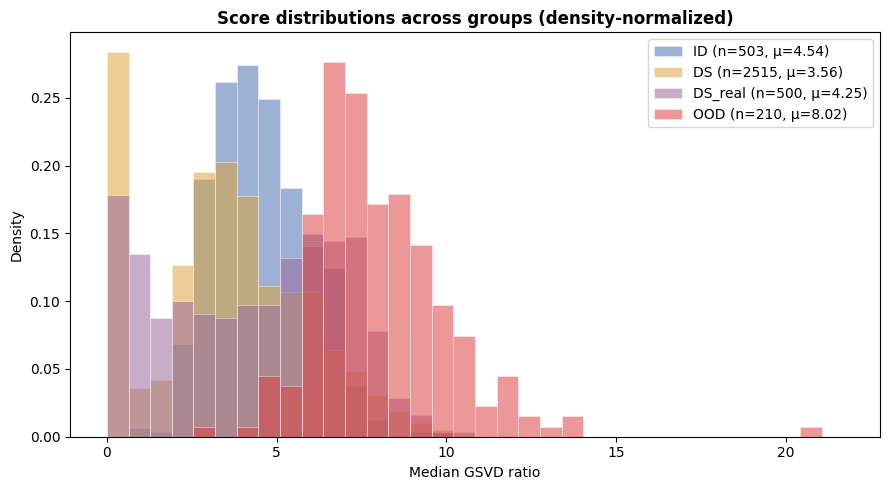

In [68]:
fig, ax = plt.subplots(figsize=(9, 5))
colors_e5 = {"ID": "#4C72B0", "DS": "#DDA43F", "DS_real": "#9B6B9E", "OOD": "#DD4444"}
all_scores = np.concatenate(list(groups.values()))
bins = np.linspace(all_scores.min() * 0.95, all_scores.max() * 1.05, 35)
for g, v in groups.items():
    ax.hist(v, bins=bins, alpha=0.55, density=True,
            label=f"{g} (n={len(v)}, μ={v.mean():.2f})",
            color=colors_e5.get(g, "gray"),
            edgecolor="white", linewidth=0.5)
ax.set_xlabel("Median GSVD ratio")
ax.set_ylabel("Density")
ax.set_title("Score distributions across groups (density-normalized)",
             fontweight="bold")
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig(os.path.join(EXP5_DIR, "three_way_histogram.pdf"), dpi=300, bbox_inches="tight")
plt.show()

### Plot 2 — pairwise ROC curves

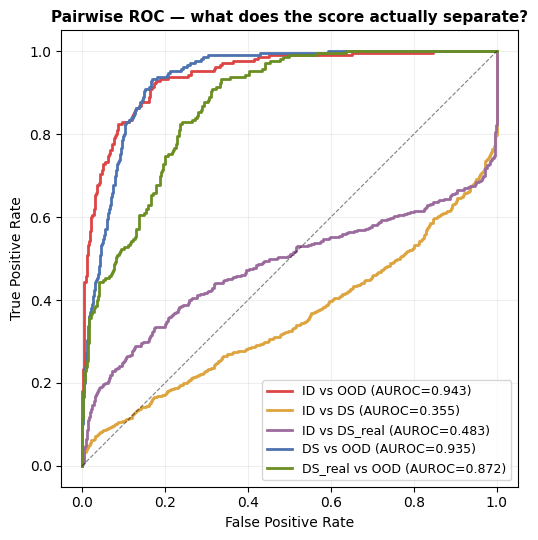

In [69]:
fig, ax = plt.subplots(figsize=(6, 5.5))
roc_pairs = [
    ("ID",      "OOD",     "#DD4444"),
    ("ID",      "DS",      "#DDA43F"),
    ("ID",      "DS_real", "#9B6B9E"),
    ("DS",      "OOD",     "#4C72B0"),
    ("DS_real", "OOD",     "#6B8E23"),
]
for neg, pos, col in roc_pairs:
    if neg in groups and pos in groups:
        y = np.concatenate([np.zeros(len(groups[neg])), np.ones(len(groups[pos]))])
        s = np.concatenate([groups[neg], groups[pos]])
        fpr, tpr, _ = roc_curve(y, s)
        a = roc_auc_score(y, s)
        ax.plot(fpr, tpr, color=col, linewidth=2,
                label=f"{neg} vs {pos} (AUROC={a:.3f})")
ax.plot([0, 1], [0, 1], "k--", alpha=0.5, linewidth=0.8)
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("Pairwise ROC — what does the score actually separate?",
             fontweight="bold", fontsize=11)
ax.legend(fontsize=9, loc="lower right")
ax.set_aspect("equal"); ax.grid(alpha=0.2)
plt.tight_layout()
plt.savefig(os.path.join(EXP5_DIR, "roc_pairwise.pdf"), dpi=300, bbox_inches="tight")
plt.show()

### Plot 3 — per-augmentation means

Which augmentations most perturb the score?

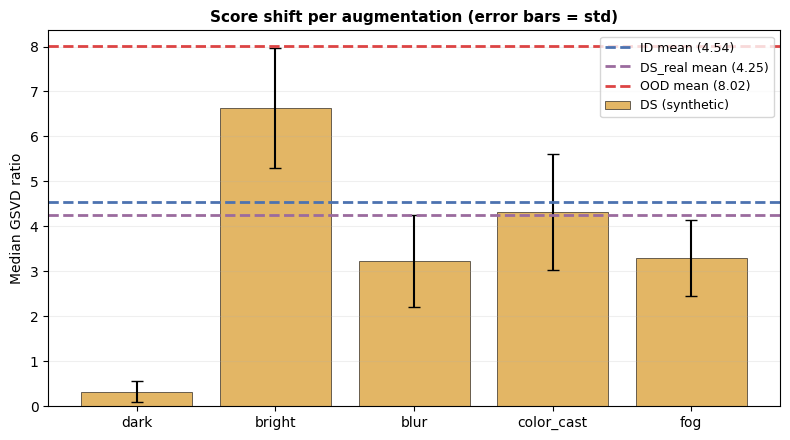

In [70]:
fig, ax = plt.subplots(figsize=(8, 4.5))
aug_names = list(AUGS.keys())
id_mean = groups["ID"].mean() if "ID" in groups else 0.0
aug_means = [np.mean([r["score"] for r in records_e5
                      if r["group"] == "DS" and r["subgroup"] == a]) for a in aug_names]
aug_stds = [np.std([r["score"] for r in records_e5
                    if r["group"] == "DS" and r["subgroup"] == a]) for a in aug_names]
x = np.arange(len(aug_names))
ax.bar(x, aug_means, yerr=aug_stds, color="#DDA43F", alpha=0.8,
       edgecolor="black", linewidth=0.5, capsize=4, label="DS (synthetic)")
ax.axhline(id_mean, color="#4C72B0", linestyle="--", linewidth=2,
           label=f"ID mean ({id_mean:.2f})")
if "DS_real" in groups:
    ax.axhline(groups["DS_real"].mean(), color="#9B6B9E", linestyle="--", linewidth=2,
               label=f"DS_real mean ({groups['DS_real'].mean():.2f})")
if "OOD" in groups:
    ax.axhline(groups["OOD"].mean(), color="#DD4444", linestyle="--", linewidth=2,
               label=f"OOD mean ({groups['OOD'].mean():.2f})")
ax.set_xticks(x); ax.set_xticklabels(aug_names)
ax.set_ylabel("Median GSVD ratio")
ax.set_title("Score shift per augmentation (error bars = std)",
             fontweight="bold", fontsize=11)
ax.legend(fontsize=9); ax.grid(alpha=0.2, axis="y")
plt.tight_layout()
plt.savefig(os.path.join(EXP5_DIR, "score_vs_augmentation.pdf"), dpi=300, bbox_inches="tight")
plt.show()

### How to interpret these numbers

| quantity | what it means |
| --- | --- |
| AUROC(ID vs OOD) | headline anomaly detection result |
| AUROC(ID vs DS) | synthetic covariate-shift robustness (≈0.5 = robust, >0.7 = method conflates shift with anomaly) |
| AUROC(ID vs DS_real) | real covariate-shift robustness (BDD100K) — the most honest number |
| AUROC(DS_real vs OOD) | can the method tell real shift from anomalies? if yes, it's doing real work |
| Per-OOD-dataset AUROCs | if Fishyscapes ≫ AnomalyTrack, method may be latching onto Fishyscapes paste artifacts |
| score vs luminance \|r\| | <0.3 = not just brightness. >0.6 = mostly brightness. |